# Field rotation vs. mount pointing (`telemetry_mining` template)

General-purpose **template** for a common shape of study, not a one-off: pick two
independent, per-exposure variables (X, Y), a third dependent variable to encode as
color, and a SQL `WHERE` clause to downselect which exposures go in. The
"Configuration" cell below is the only place you should need to edit to repurpose
this for a different triplet of variables -- everything after it is generic.

**Worked example**: does the field-rotation rate depend on where the telescope is
pointing? `X = mount hour angle`, `Y = mount declination`, color = `rotator rate`,
restricted to real DESI science exposures with enough accumulated signal
(`sequence = 'DESI' and totteff > 60`).

All three variables here are per-exposure scalars already sitting in
`exposure.exposure` (the DB row `select_exposures` fetches for its `WHERE` filter
anyway) -- so, unlike most of the sibling notebooks in this folder, this one never
opens a FITS file or queries any other table. If you repurpose this template with a
variable that needs cframe/GFA/telemetry access instead, expect it to cost one
round-trip per exposure, same as elsewhere in this package (see `API.md`'s "Caching
and cost model").

**A real gotcha, confirmed against the live DB while building this example**:
`exposure.exposure` has a top-level `rotrate` column that looks like the obvious
source for "rotator rate" -- but it's dead data, a known bug in the online exposure
DB ingestion (only 1 non-null value in the entire 361,939-row table's history). The
correct, DB-resident source is `hexapod['rot_rate']` -- the online code writes the
whole `hexapod` request dict into that jsonb column as-is, and `rot_rate` is one of
its real keys. `hexapod` isn't populated for every exposure sequence (by design, not
a bug), so this notebook simply skips any exposure where it -- or `mount_ha`/
`mount_dec` -- is missing, rather than treating that as an error.

Also worth noting: `mount_ha`/`mount_dec` here come from the `tcs` jsonb block, not
the flat `mountha` column that also exists on `exposure.exposure` -- there's no flat
`mountdec` counterpart at all, so `tcs['mount_ha']`/`tcs['mount_dec']` is the
consistent pair to use.

In [37]:
import os
import sys

# Add telemetry_mining to the path. Point DOS_TELEMETRY_MINING_DIR at your own
# checkout (svn co https://desi.lbl.gov/svn/code/online/telemetry_mining/trunk);
# defaults to the maintainer's checkout at NERSC.
TM_DIR = os.getenv("DOS_TELEMETRY_MINING_DIR", os.path.expanduser("~/telemetry_mining-trunk/src"))
sys.path.insert(0, TM_DIR)

## Configuration -- edit this cell to repurpose the notebook

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from telemetry_mining import select_exposures

# ---- Exposure selection: set exactly one of NIGHT_RANGE / EXPIDS ----
NIGHT_RANGE = [20240101, 20260701]   # e.g. (20260101, 20260710), inclusive
EXPIDS = None                        # e.g. an explicit exposure list

# Extra WHERE-clause fragment, ANDed with the night/expid selection above.
# Parameterize actual values via WHERE_PARAMS, same convention as select_exposures.
WHERE_EXTRA = "sequence = %s and totteff > %s and (program like %s or program like %s)"
WHERE_PARAMS = ('DESI', 60.0,'DARK','BRIGHT')
#WHERE_EXTRA = "sequence = %s and totteff > %s"
#WHERE_PARAMS = ('DESI', 60.0)

# ---- The three variables -- this is the part to change for a different study ----
# Each *_SPEC is a dotted-path string into one Exposure, resolved by
# telemetry_mining.query.resolve_spec (see its docstring for the full mini-language,
# e.g. "header.ETCFRACB", "gfa_row.FWHM_ASEC", "db_row.hexapod['hex_trim'][2]") --
# or a plain callable(Exposure) -> value for anything the mini-language can't express.
# Must be per-exposure scalars (one value per EXPID), not per-fiber/per-petal.
X_SPEC, X_LABEL = "db_row.tcs['mount_ha']", "Mount hour angle (deg)"
Y_SPEC, Y_LABEL = "db_row.tcs['mount_dec']", "Mount declination (deg)"
C_SPEC, C_LABEL = "db_row.hexapod['rot_rate']", "Rotator rate (arcsec/min)"

# ---- Plot ----
PLOT_MODE = "heatmap"   # "scatter" or "heatmap"
HEATMAP_BINS = 60       # only used for PLOT_MODE == "heatmap"
HEATMAP_STAT = "mean"   # any statistic scipy.stats.binned_statistic_2d accepts

## Select exposures + resolve the three variables

One `select_exposures` call does the whole job: the `WHERE` filter (night/expid range
plus `WHERE_EXTRA`) and all three column specs resolve against the same bulk
`exposure.exposure` query, so this cell costs exactly one round-trip to the DB no
matter how many exposures match. `on_error="skip"` drops (and records) any exposure
where a spec fails outright (e.g. a jsonb key genuinely missing); rows where a spec
resolved to SQL NULL/`None` are dropped separately below, since `on_error` only
catches exceptions, not None values.

In [57]:
assert (NIGHT_RANGE is None) != (EXPIDS is None), "set exactly one of NIGHT_RANGE or EXPIDS, not both/neither"

if NIGHT_RANGE is not None:
    where = f"night between %s and %s and ({WHERE_EXTRA})"
    params = (NIGHT_RANGE[0], NIGHT_RANGE[1]) + tuple(WHERE_PARAMS)
else:
    where = f"id = ANY(%s) and ({WHERE_EXTRA})"
    params = (list(EXPIDS),) + tuple(WHERE_PARAMS)

selection = select_exposures(
    where,
    columns={"X": X_SPEC, "Y": Y_SPEC, "C": C_SPEC},
    params=params,
    on_error="skip",
)
skipped = selection.attrs["skipped"]
df = selection.dropna(subset=["X", "Y", "C"])

shown = list(skipped)[:10]
print(f'{len(selection)} exposures matched, {len(skipped)} skipped on error '
      f'({shown}{"..." if len(skipped) > 10 else ""}), '
      f'{len(selection) - len(df)} more dropped for a missing X/Y/C value '
      f'-> {len(df)} exposures to plot')
df.head()

7558 exposures matched, 0 skipped on error ([]), 0 more dropped for a missing X/Y/C value -> 7558 exposures to plot


,EXPID,NIGHT,X,Y,C
0,216970,20240102,3.414330,-8.31957,0.458
1,216971,20240102,6.837469,-15.24772,0.445
2,216972,20240102,7.719700,-12.01721,0.443
3,216973,20240102,11.909845,-11.76735,0.425
4,216974,20240102,14.012284,-15.68835,0.411


## Plot

`PLOT_MODE = "scatter"`: one point per exposure, color-coded by `C`. Best for a
moderate number of exposures where individual points are still meaningful.

`PLOT_MODE = "heatmap"`: bins X/Y into a grid and colors each cell by `HEATMAP_STAT`
(mean by default) of `C` within that cell, via `scipy.stats.binned_statistic_2d` --
better once there are enough exposures that a scatter plot turns into an
indistinguishable blob. Stays within this project's existing dependencies
(matplotlib + scipy, both already used elsewhere in `notebooks/`) rather than
pulling in a new plotting library.

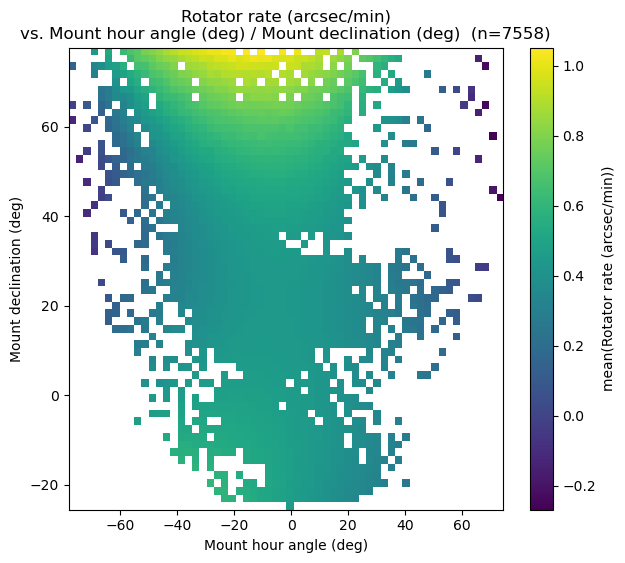

In [58]:
if PLOT_MODE == "scatter":
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(df["X"], df["Y"], c=df["C"], cmap="viridis", s=15)
    plt.colorbar(sc, label=C_LABEL)
elif PLOT_MODE == "heatmap":
    from scipy.stats import binned_statistic_2d
    stat, xedges, yedges, _ = binned_statistic_2d(
        df["X"], df["Y"], df["C"], statistic=HEATMAP_STAT, bins=HEATMAP_BINS
    )
    plt.figure(figsize=(7, 6))
    im = plt.imshow(
        stat.T, origin="lower", aspect="auto",
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap="viridis",
    )
    plt.colorbar(im, label=f"{HEATMAP_STAT}({C_LABEL})")
else:
    raise ValueError(f"PLOT_MODE must be 'scatter' or 'heatmap', got {PLOT_MODE!r}")

plt.xlabel(X_LABEL)
plt.ylabel(Y_LABEL)
plt.title(f"{C_LABEL}\nvs. {X_LABEL} / {Y_LABEL}  (n={len(df)})")
plt.show()

## Recap

How to repurpose this notebook for a different triplet of per-exposure variables:

1. Change `X_SPEC`/`Y_SPEC`/`C_SPEC` (+ their `_LABEL`s) in the Configuration cell --
   any dotted path `telemetry_mining.query.resolve_spec` understands, or a callable
   for anything fancier.
2. Change `WHERE_EXTRA`/`WHERE_PARAMS` for a different downselection.
3. Everything else (exposure selection, plotting) is generic and untouched.

**Constraint worth restating**: this template only works for **per-exposure**
variables (one value per EXPID) -- `select_exposures` builds exactly one row per
exposure. A per-fiber/per-petal quantity (e.g. anything from
`cframe_table`/`fiberqa_table`) needs a different shape entirely -- see
`calibstars_linphi.ipynb`/`fiberflux_ratio_linphi.ipynb` for that pattern
(`harvest(..., concat=True)` pooling many rows per exposure).

### Result

_Run the notebook (see `notebooks/README.md` for the headless `jupyter nbconvert`
recipe) and record the actual field-rotation-vs-pointing finding here._